# Balancing Market & Risk Metrics

This notebook covers two essential topics for power traders:

| # | Topic | Key question |
|---|-------|--------------|
| 1 | **Balancing Market** | How does the TSO maintain grid frequency in real time? |
| 2 | **VaR & CVaR** | How much can I lose on a bad day? |

**Data source:** SMARD API (Bundesnetzagentur) — German electricity market  
**Period:** Last 52 weeks of hourly data

In [2]:
import requests
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt

plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
print('Libraries loaded.')

Libraries loaded.


---
## Part 1 — Balancing Market

### Why does the balancing market exist?

Every market participant commits to a position in the **day-ahead market** (closes 12:00).  
Real-time production and consumption always deviate from the plan.  
The TSO must correct these deviations **instantly** to maintain grid frequency at 50 Hz.

The TSO does not do this alone — it contracts **reserves** from flexible generators and consumers in advance.

### Three reserve products (Germany / ENTSO-E standard):

| Product | Response time | Activation | Payment |
|---------|--------------|------------|---------|
| **FCR** — Frequency Containment Reserve | 30 seconds | Automatic (frequency deviation) | Capacity only |
| **aFRR** — automatic Frequency Restoration Reserve | 5 minutes | Automatic (TSO signal) | Capacity + activation |
| **mFRR** — manual Frequency Restoration Reserve | 12.5 minutes | Manual (TSO call) | Capacity + activation (highest) |

### Who can participate?

| Asset | FCR | aFRR | mFRR |
|-------|-----|------|------|
| Battery storage | ✓ | ✓ | ✓ |
| Gas peaker | ✓ | ✓ | ✓ |
| Pumped hydro | ✓ | ✓ | ✓ |
| Wind farm | ✗ | ✗ | ~ |
| Solar farm | ✗ | ✗ | ~ |

Wind and solar cannot guarantee availability → cannot offer FCR/aFRR.

In [3]:
# Balancing market economics — battery storage example

battery_mw        = 50    # MW capacity
hours_per_week    = 168

# Reserve capacity prices (approximate, EUR/MW/hour)
fcr_capacity_price  = 15.0   # EUR/MW/hour
afrr_capacity_price = 8.0
mfrr_capacity_price = 5.0

# Day-ahead arbitrage alternative
# From our earlier analysis: avg peak/off-peak spread ~92 EUR/MWh
da_spread_eur_mwh = 92
daily_cycles      = 1     # 1 charge/discharge cycle per day

# Weekly revenue comparison
fcr_weekly  = battery_mw * fcr_capacity_price  * hours_per_week
afrr_weekly = battery_mw * afrr_capacity_price * hours_per_week
da_weekly   = battery_mw * da_spread_eur_mwh   * daily_cycles * 7

print('── Battery revenue comparison (50 MW) ─────────────')
print(f'FCR capacity payment : {fcr_weekly:>10,.0f} EUR/week')
print(f'aFRR capacity payment: {afrr_weekly:>10,.0f} EUR/week')
print(f'Day-ahead arbitrage  : {da_weekly:>10,.0f} EUR/week')
print(f'\nFCR vs day-ahead     : {fcr_weekly/da_weekly:.1f}x more profitable')
print(f'\nNote: FCR also requires activation payments when called.')
print(f'But activation = battery cycles = degradation cost.')
print(f'Real decision: FCR capacity fee vs battery wear and tear.')

── Battery revenue comparison (50 MW) ─────────────
FCR capacity payment :    126,000 EUR/week
aFRR capacity payment:     67,200 EUR/week
Day-ahead arbitrage  :     32,200 EUR/week

FCR vs day-ahead     : 3.9x more profitable

Note: FCR also requires activation payments when called.
But activation = battery cycles = degradation cost.
Real decision: FCR capacity fee vs battery wear and tear.


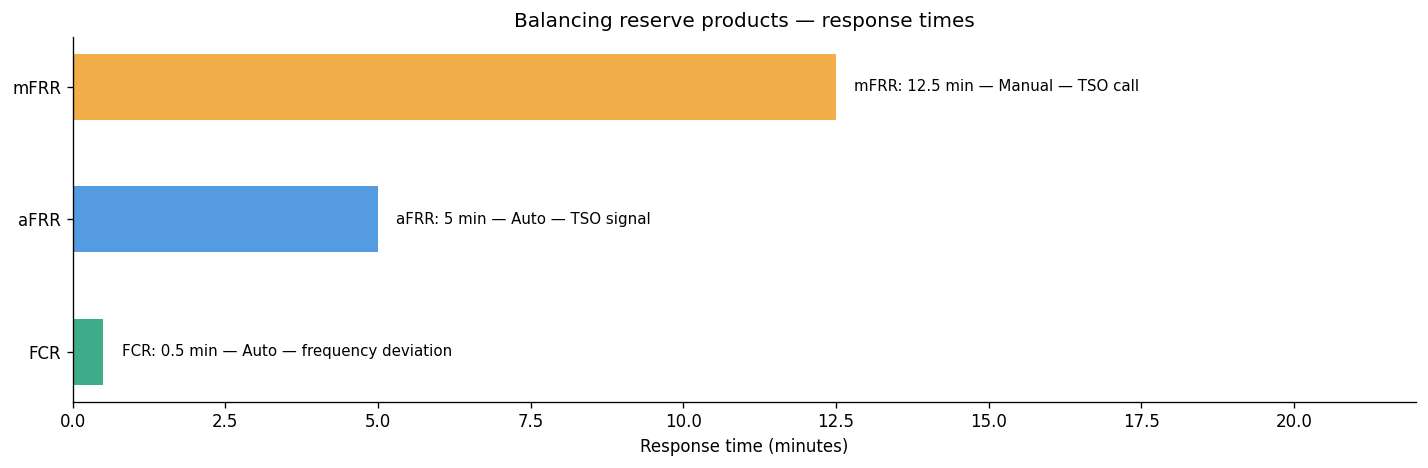

In [4]:
# Visualise: reserve products timeline
fig, ax = plt.subplots(figsize=(12, 4))

products = [
    ('FCR',  0.5,  '#1D9E75', 'Auto — frequency deviation'),
    ('aFRR', 5,    '#378ADD', 'Auto — TSO signal'),
    ('mFRR', 12.5, '#EF9F27', 'Manual — TSO call'),
]

for i, (name, response, color, trigger) in enumerate(products):
    ax.barh(i, response, color=color, alpha=0.85, height=0.5)
    ax.text(response + 0.3, i, f'{name}: {response} min — {trigger}',
            va='center', fontsize=9)

ax.set_yticks(range(len(products)))
ax.set_yticklabels([p[0] for p in products])
ax.set_xlabel('Response time (minutes)')
ax.set_title('Balancing reserve products — response times')
ax.set_xlim(0, 22)
plt.tight_layout()
plt.show()

---
## Part 2 — VaR & CVaR

### What is risk in power trading?

Risk = the possibility that the actual outcome is worse than expected.

In power trading, the main risks are:
- **Price risk** — price moves against your position
- **Volume risk** — you cannot produce/consume the committed amount
- **Liquidity risk** — no counterparty available when you need to close
- **Counterparty risk** — buyer/seller defaults

### VaR — Value at Risk

> "With 95% confidence, my maximum loss in one period is X EUR."

In other words: in 100 trading periods, 95 will have losses smaller than VaR.
The remaining 5 may exceed it.

### CVaR — Conditional Value at Risk (Expected Shortfall)

> "In the worst 5% of scenarios, my average loss is X EUR."

CVaR answers what VaR ignores: *how bad does it get when things go wrong?*

### Decision rule:
```
CVaR > available capital  →  position too large, reduce size
CVaR < available capital  →  position acceptable
```

In [5]:
# Fetch 1 year of German day-ahead prices
def fetch_smard(filter_no, col_name, weeks=52):
    url_index = f'https://www.smard.de/app/chart_data/{filter_no}/DE/index_hour.json'
    timestamps = requests.get(url_index).json()['timestamps']
    selected = timestamps[-weeks:]
    series = []
    for i, ts in enumerate(selected):
        url = f'https://www.smard.de/app/chart_data/{filter_no}/DE/{filter_no}_DE_hour_{ts}.json'
        series.extend(requests.get(url).json()['series'])
        time.sleep(0.3)
        if i % 10 == 0:
            print(f'  {col_name}: {i+1}/{weeks} blocks...')
    df = pd.DataFrame(series, columns=['timestamp_ms', col_name])
    df['datetime'] = pd.to_datetime(df['timestamp_ms'], unit='ms')
    return df[['datetime', col_name]].dropna()

print('Fetching price data...')
df_price = fetch_smard(4169, 'price_eur_mwh')
print(f'Dataset: {len(df_price)} hours')

Fetching price data...
  price_eur_mwh: 1/52 blocks...
  price_eur_mwh: 11/52 blocks...
  price_eur_mwh: 21/52 blocks...
  price_eur_mwh: 31/52 blocks...
  price_eur_mwh: 41/52 blocks...
  price_eur_mwh: 51/52 blocks...
Dataset: 8664 hours


In [6]:
# VaR & CVaR calculation
# Use absolute price changes (not % — negative prices break pct_change)

price_changes = df_price['price_eur_mwh'].diff().dropna()
price_changes = price_changes.replace([np.inf, -np.inf], np.nan).dropna()

confidence = 0.95
VaR_mwh  = np.percentile(price_changes, (1 - confidence) * 100)
CVaR_mwh = price_changes[price_changes <= VaR_mwh].mean()

# Scale to position sizes
positions = [10, 50, 100, 500]

print(f'── Price change statistics ────────────────────────')
print(f'Mean hourly change : {price_changes.mean():.2f} EUR/MWh')
print(f'Std deviation      : {price_changes.std():.2f} EUR/MWh')
print(f'Min change         : {price_changes.min():.2f} EUR/MWh')
print(f'Max change         : {price_changes.max():.2f} EUR/MWh')
print(f'\n── Risk metrics ───────────────────────────────────')
print(f'VaR  (95%)         : {VaR_mwh:.2f} EUR/MWh')
print(f'CVaR (95%)         : {CVaR_mwh:.2f} EUR/MWh')
print(f'\n── Position risk table ────────────────────────────')
print(f'{"Position":>12}  {"VaR (EUR)":>12}  {"CVaR (EUR)":>12}')
print('-' * 40)
for pos in positions:
    var_eur  = abs(VaR_mwh)  * pos
    cvar_eur = abs(CVaR_mwh) * pos
    print(f'{pos:>10} MWh  {var_eur:>10,.0f} EUR  {cvar_eur:>10,.0f} EUR')

── Price change statistics ────────────────────────
Mean hourly change : -0.00 EUR/MWh
Std deviation      : 21.30 EUR/MWh
Min change         : -241.65 EUR/MWh
Max change         : 217.05 EUR/MWh

── Risk metrics ───────────────────────────────────
VaR  (95%)         : -28.41 EUR/MWh
CVaR (95%)         : -48.25 EUR/MWh

── Position risk table ────────────────────────────
    Position     VaR (EUR)    CVaR (EUR)
----------------------------------------
        10 MWh         284 EUR         482 EUR
        50 MWh       1,420 EUR       2,412 EUR
       100 MWh       2,841 EUR       4,825 EUR
       500 MWh      14,204 EUR      24,123 EUR


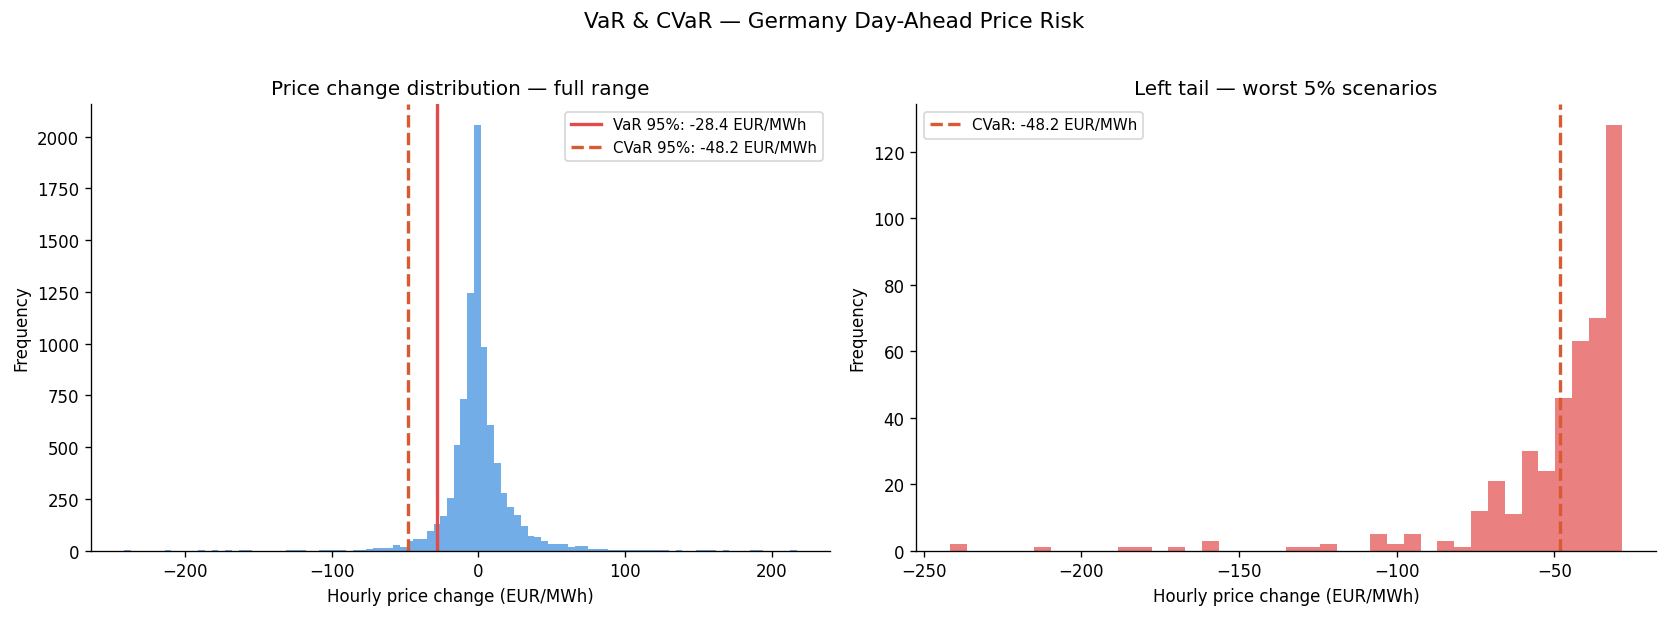

In [7]:
# Visualise price change distribution with VaR and CVaR
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: full distribution
axes[0].hist(price_changes, bins=100, color='#378ADD', alpha=0.7, edgecolor='none')
axes[0].axvline(VaR_mwh,  color='#E24B4A', linewidth=2,
                label=f'VaR 95%: {VaR_mwh:.1f} EUR/MWh')
axes[0].axvline(CVaR_mwh, color='#D85A30', linewidth=2, linestyle='--',
                label=f'CVaR 95%: {CVaR_mwh:.1f} EUR/MWh')
axes[0].set_xlabel('Hourly price change (EUR/MWh)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Price change distribution — full range')
axes[0].legend(fontsize=9)

# Plot 2: left tail zoom
tail = price_changes[price_changes <= VaR_mwh]
axes[1].hist(tail, bins=40, color='#E24B4A', alpha=0.7, edgecolor='none')
axes[1].axvline(CVaR_mwh, color='#D85A30', linewidth=2, linestyle='--',
                label=f'CVaR: {CVaR_mwh:.1f} EUR/MWh')
axes[1].set_xlabel('Hourly price change (EUR/MWh)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Left tail — worst 5% scenarios')
axes[1].legend(fontsize=9)

plt.suptitle('VaR & CVaR — Germany Day-Ahead Price Risk', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

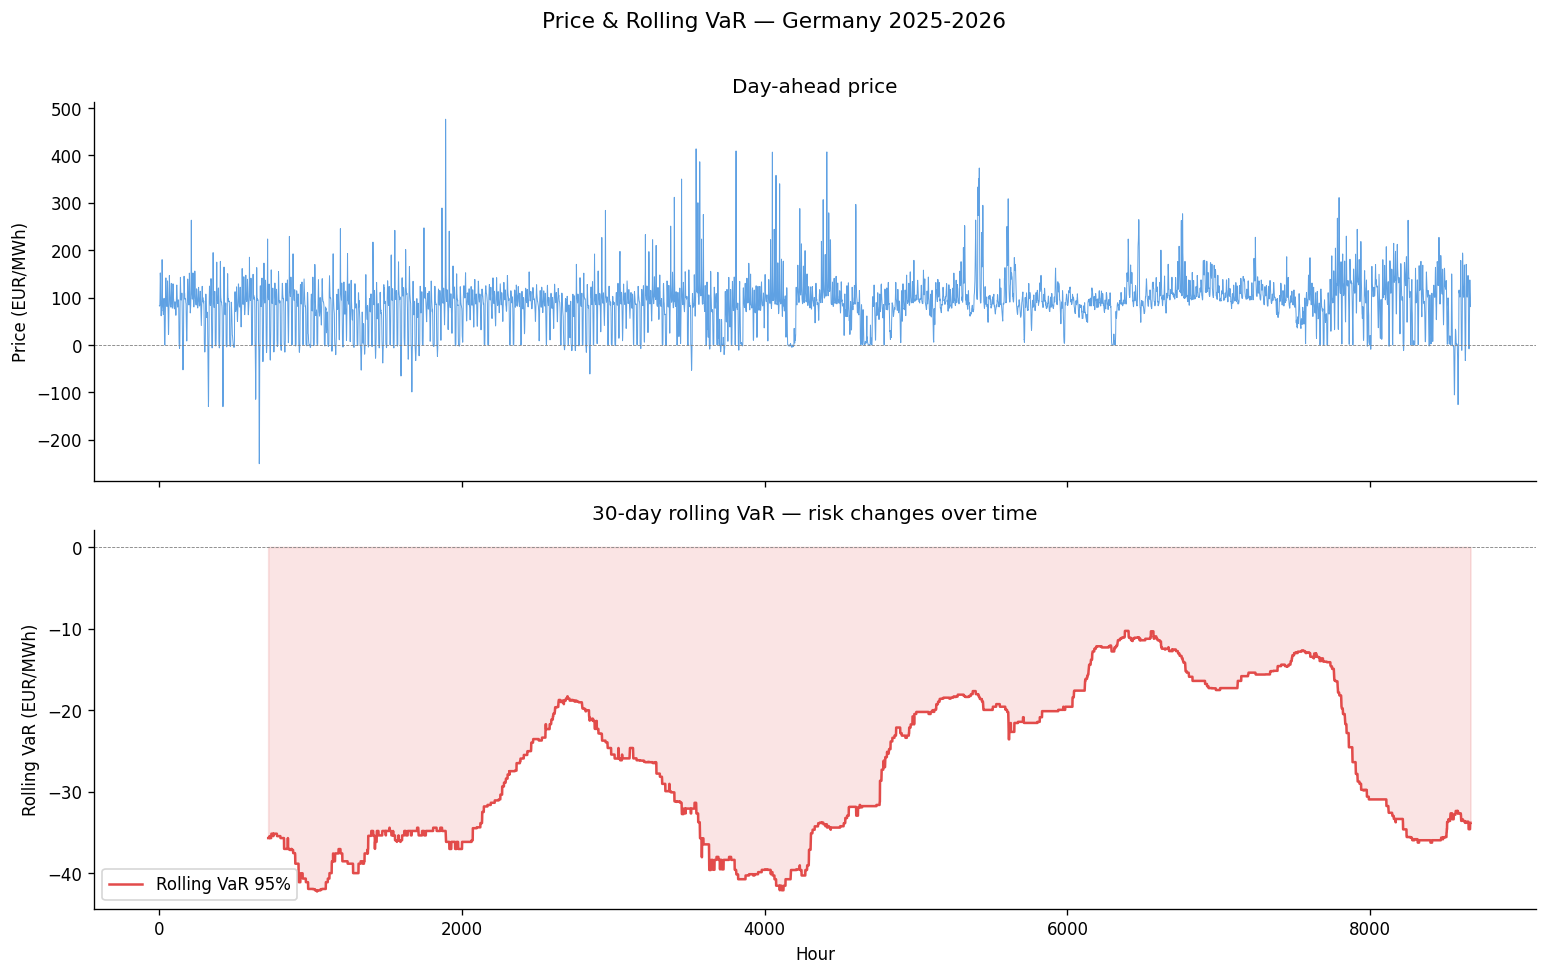

Key insight: VaR is not constant — risk spikes in spring (solar volatility)
A trader must update risk limits dynamically, not set them once and forget.


In [8]:
# Rolling VaR — how does risk change over time?
window = 24 * 30  # 30-day rolling window

rolling_var  = price_changes.rolling(window).quantile(0.05)
rolling_mean = price_changes.rolling(window).mean()

df_price['hour_idx'] = range(len(df_price))
idx = df_price['hour_idx'].values[1:]

fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

# Price
axes[0].plot(idx, df_price['price_eur_mwh'].values[1:],
             color='#378ADD', linewidth=0.6, alpha=0.8)
axes[0].axhline(0, color='gray', linewidth=0.5, linestyle='--')
axes[0].set_ylabel('Price (EUR/MWh)')
axes[0].set_title('Day-ahead price')

# Rolling VaR
axes[1].plot(idx, rolling_var.values,
             color='#E24B4A', linewidth=1.5, label='Rolling VaR 95%')
axes[1].fill_between(idx, rolling_var.values, 0,
                     where=(rolling_var.values < 0),
                     alpha=0.15, color='#E24B4A')
axes[1].axhline(0, color='gray', linewidth=0.5, linestyle='--')
axes[1].set_ylabel('Rolling VaR (EUR/MWh)')
axes[1].set_xlabel('Hour')
axes[1].set_title('30-day rolling VaR — risk changes over time')
axes[1].legend()

plt.suptitle('Price & Rolling VaR — Germany 2025-2026', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print('Key insight: VaR is not constant — risk spikes in spring (solar volatility)')
print('A trader must update risk limits dynamically, not set them once and forget.')

---
## Summary

| Topic | Key takeaway |
|-------|--------------|
| Balancing market | TSO maintains frequency via pre-contracted reserves (FCR → aFRR → mFRR) |
| Reserve eligibility | Only firm, fast-responding assets qualify for FCR/aFRR |
| Battery economics | FCR capacity payments can be 4x more profitable than day-ahead arbitrage |
| VaR | Threshold: 95% of periods, loss stays below this level |
| CVaR | When things go wrong: average loss in worst 5% scenarios |
| Rolling VaR | Risk is dynamic — highest in spring due to solar volatility |

---
## Next steps

- **Intraday market** — how does the price evolve between day-ahead and delivery?
- **Position limits** — how do trading firms set max exposure per trader?
- **ENTSO-E cross-border** — fetch real FR/NL prices, calculate live arbitrage windows

> Data source: [SMARD Bundesnetzagentur](https://www.smard.de)